# QRC Image Denoising — EuroSAT

Extending Soumyadip Das et al. hybrid QRC pipeline to EuroSAT dataset.

Pipeline:
1. **PCA** — 100 components, fit on clean train
2. **QRC** — first `d ≤ 18` PCA components → Rydberg reservoir → embedding
3. **MLP readout** — embedding → 64×64 denoised image

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # silence TF C++ stdout/stderr spam (pipe backpressure)
import random
import numpy as np
import tensorflow as tf
from pathlib import Path
from PIL import Image
import zipfile
from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# let TF grow VRAM on demand instead of pre-grabbing (4 GB GPU)
for _g in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_g, True)


In [ ]:
# ── Experiment config ──────────────────────────────────────────────────────────
SIGMA = 0.7   # multiplicative speckle noise std — change to run different noise levels
D_QRC = 18    # qubits / PCA components fed to reservoir
# ───────────────────────────────────────────────────────────────────────────────


### Dataset - Load & Split

In [2]:
def to_grayscale(X_rgb: np.ndarray) -> np.ndarray:
    """Rec.601 luminance. Input: (..., 3) float32. Output: (...) float32."""
    return 0.299 * X_rgb[..., 0] + 0.587 * X_rgb[..., 1] + 0.114 * X_rgb[..., 2]


DATA_DIR = Path("data/EuroSAT_RGB")
ZIP_PATH = Path("data_zip/EuroSAT_RGB.zip")
MODEL_DIR = Path("models/eurosat_qrc")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR.exists() and any(DATA_DIR.iterdir())):
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR.parent)

CATEGORIES = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
LABEL_MAP  = {cat: i for i, cat in enumerate(CATEGORIES)}
print("Categories:", CATEGORIES)

images, labels = [], []
for cat in CATEGORIES:
    for path in sorted((DATA_DIR / cat).glob("*.jpg")):
        img = np.array(Image.open(path).resize((64, 64)), dtype=np.float32) / 255.0
        images.append(img)
        labels.append(LABEL_MAP[cat])

X_rgb = np.stack(images)   # (N, 64, 64, 3)
y     = np.array(labels)   # (N,)

X = to_grayscale(X_rgb)    # (N, 64, 64)
print(f"Total: {X.shape}, labels: {y.shape}")

# 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Categories: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total: (27000, 64, 64), labels: (27000,)
Train: (21600, 64, 64), Val: (2700, 64, 64), Test: (2700, 64, 64)


### Noise Dataset

In [3]:
def apply_noise(X: np.ndarray, sigma: float, seed: int) -> np.ndarray:
    """I˜ = clip(I · (1 + σ · N(0,1)), 0, 1). X must be float32 in [0,1]."""
    rng = np.random.default_rng(seed)
    eps = rng.normal(0, sigma, size=X.shape).astype(np.float32)
    return np.clip(X * (1 + eps), 0.0, 1.0)

In [ ]:
X_train_noisy = apply_noise(X_train, sigma=SIGMA, seed=SEED)
X_val_noisy   = apply_noise(X_val,   sigma=SIGMA, seed=SEED + 1)
X_test_noisy  = apply_noise(X_test,  sigma=SIGMA, seed=SEED + 2)
print(f"Train noisy: {X_train_noisy.shape}, Val noisy: {X_val_noisy.shape}, Test noisy: {X_test_noisy.shape}")


Visualização

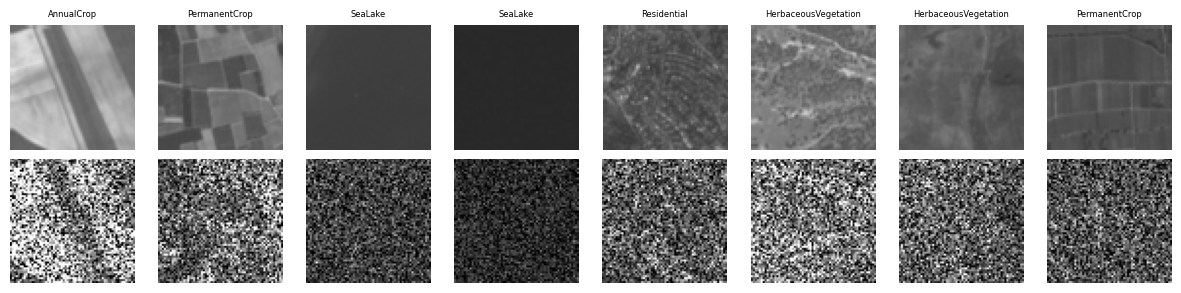

In [5]:
import matplotlib.pyplot as plt

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))

for col in range(n):
    axes[0, col].imshow(X_train[col],       cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_train_noisy[col], cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(CATEGORIES[y_train[col]], fontsize=6)
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("clean", fontsize=9)
axes[1, 0].set_ylabel("noisy", fontsize=9)
plt.tight_layout()
plt.show()

### PCA

In [6]:
from sklearn.decomposition import PCA

N_COMPONENTS = 100

X_train_flat = X_train.reshape(X_train.shape[0], -1)

pca = PCA(n_components=N_COMPONENTS)
pca.fit(X_train_flat)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",100
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

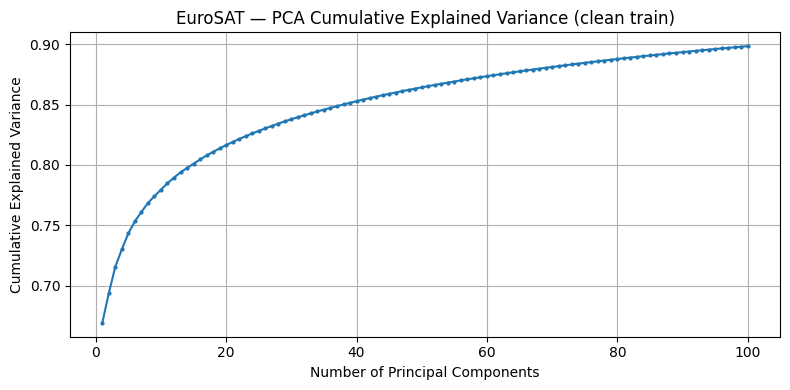

Variance explained by 100 PCs: 0.8983
Explained variance ratio added at each PC (10 first): [0.6690509  0.02467677 0.02198641 0.01423048 0.01338855 0.00990547
 0.00774623 0.00741209 0.00566784 0.00539537]


In [7]:
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, N_COMPONENTS + 1), cumulative_var, marker=".", markersize=4)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("EuroSAT — PCA Cumulative Explained Variance (clean train)")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Variance explained by {N_COMPONENTS} PCs: {cumulative_var[-1]:.4f}")
print(f"Explained variance ratio added at each PC (10 first): {pca.explained_variance_ratio_[:10]}")

The variance explained by the principal components is significantly higher then the values observed on MNIST.

The high value of variance explained by the first PC indicates there is an axis along which the images are very spread out.

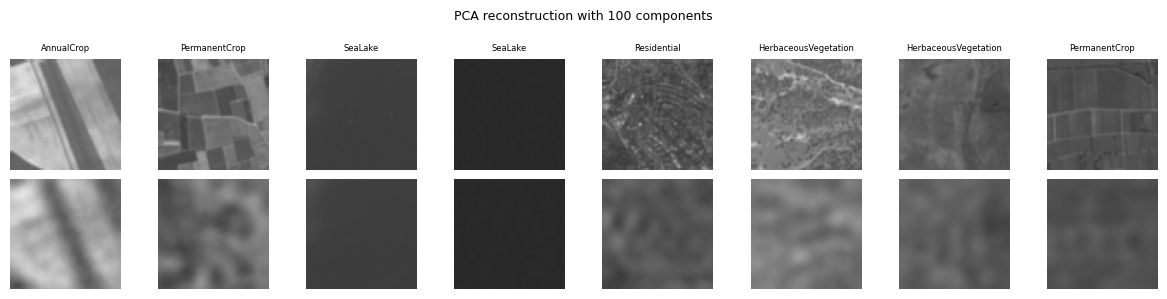

In [8]:
X_train_projected = pca.transform(X_train_flat)  # (n_train, N_COMPONENTS)

X_train_reconstructed = pca.inverse_transform(X_train_projected)  # (n_train, 4096)

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))

for col in range(n):
    axes[0, col].imshow(X_train[col],                               cmap="gray", vmin=0, vmax=1)
    axes[1, col].imshow(X_train_reconstructed[col].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(CATEGORIES[y_train[col]], fontsize=6)
    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("original", fontsize=8)
axes[1, 0].set_ylabel(f"{N_COMPONENTS} PCs", fontsize=8)
plt.suptitle(f"PCA reconstruction with {N_COMPONENTS} components", fontsize=9)
plt.tight_layout()
plt.show()

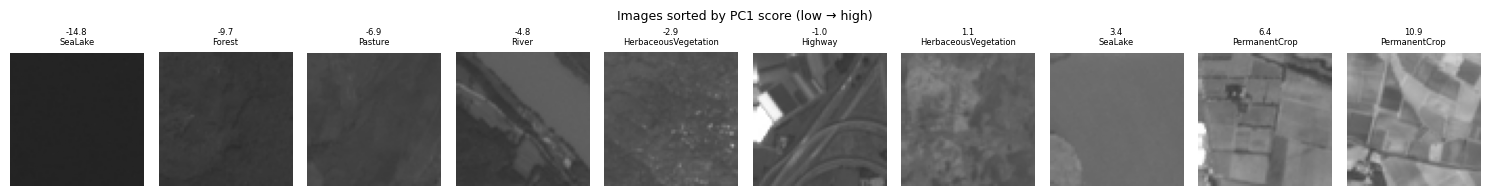

In [9]:
scores_pc1 = pca.transform(X_train_flat)[:, 0]
sorted_idx  = np.argsort(scores_pc1)

n = 10
sample_idx = [sorted_idx[int(i * len(sorted_idx) / n)] for i in range(n)]

fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 2))

for col, idx in enumerate(sample_idx):
    axes[col].imshow(X_train[idx], cmap="gray", vmin=0, vmax=1)
    axes[col].set_title(f"{scores_pc1[idx]:.1f}\n{CATEGORIES[y_train[idx]]}", fontsize=6)
    axes[col].axis("off")

plt.suptitle("Images sorted by PC1 score (low → high)", fontsize=9)
plt.tight_layout()
plt.show()

The visualisations seems to indicate the first PC represents a measure of brightness in the image.

### PCA Projections — All Splits

Project noisy images for train, val and test. These are the inputs for the QRC reservoir in the next step.

Note: PCA was fitted on **clean** train images. Noisy images are projected onto the same basis.

In [10]:
X_train_flat       = X_train.reshape(X_train.shape[0], -1)             # (21600, 4096)
X_val_flat         = X_val.reshape(X_val.shape[0], -1)                 # (2700, 4096)
X_test_flat        = X_test.reshape(X_test.shape[0], -1)               # (2700, 4096)

X_train_noisy_flat = X_train_noisy.reshape(X_train_noisy.shape[0], -1) # (21600, 4096)
X_val_noisy_flat   = X_val_noisy.reshape(X_val_noisy.shape[0], -1)     # (2700, 4096)
X_test_noisy_flat  = X_test_noisy.reshape(X_test_noisy.shape[0], -1)   # (2700, 4096)

X_train_noisy_pca = pca.transform(X_train_noisy_flat)  # (21600, 100)
X_val_noisy_pca   = pca.transform(X_val_noisy_flat)    # (2700, 100)
X_test_noisy_pca  = pca.transform(X_test_noisy_flat)   # (2700, 100)

print(f"Train PCA: {X_train_noisy_pca.shape}")
print(f"Val PCA:   {X_val_noisy_pca.shape}")
print(f"Test PCA:  {X_test_noisy_pca.shape}")

Train PCA: (21600, 100)
Val PCA:   (2700, 100)
Test PCA:  (2700, 100)


### QRC Reservoir — d = 18

Rydberg-inspired reservoir. Hamiltonian (matches Das et al.):

$$H(z) = \Omega \sum_i X_i + \sum_i \frac{\Delta_i(z_i)}{2} Z_i + \sum_{i<j} V_{ij} \, n_i n_j$$

where $\Delta_i(z_i) = \Delta_0 - k \cdot z_i$, $V_{ij} = V_0 / |i-j|^6$, $n_i = (1+Z_i)/2$.

Implementation uses `scipy.sparse` + `expm_multiply` — no Qiskit dependency. `H_fixed` (Rabi + interactions + constant detuning diagonal) is built once at init. Per-image cost is one sparse diagonal update + `n_steps` calls to `expm_multiply`.

> **Compute note:** d=18 → dim=262144. Each image ~3–10 s single-threaded. Full train set (21600 images) requires parallelisation — added in the next step.

In [11]:
from dataclasses import dataclass
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import expm_multiply


@dataclass
class QRCConfig:
    n_qubits: int = 18
    n_steps: int = 8
    dt: float = 0.5
    omega: float = 2 * np.pi       # Rabi frequency (rad/μs)
    global_detuning: float = 4.5   # Δ₀ (rad/μs)
    detuning_scale: float = 9.0    # k  (rad/μs)
    interaction_strength: float = 5.42  # rad/μs: C6/a^6, C6/2π=862690 MHz·μm⁶, a=10μm spacing
    interaction_power: float = 6.0
    shots: int | None = None       # None = exact expectation values
    seed: int = SEED


class RydbergReservoir:
    """
    Simulates a 1D Rydberg-atom chain as a quantum reservoir.
    H_fixed is built once; per-image cost is a diagonal update + n_steps expm_multiply calls.
    """

    def __init__(self, config: QRCConfig):
        self.cfg = config
        n, dim = config.n_qubits, 2 ** config.n_qubits
        self.dim = dim
        self.rng = np.random.default_rng(config.seed)

        # Z eigenvalue vectors: Z_eigs[i, state] = ±1
        self._Z_eigs = np.stack([self._z_eig(i, n, dim) for i in range(n)])  # (n, dim)

        # Build constant part of Hamiltonian (sparse)
        self._H_fixed = self._build_H_fixed()

        # Observable diagonals: ⟨Zᵢ⟩ then ⟨ZᵢZⱼ⟩ for all i<j
        self._obs = list(self._Z_eigs)
        for i in range(n):
            for j in range(i + 1, n):
                self._obs.append(self._Z_eigs[i] * self._Z_eigs[j])

        n_obs = len(self._obs)
        self.embed_dim = config.n_steps * n_obs
        print(
            f"RydbergReservoir: d={n}, dim={dim}, "
            f"obs={n_obs} ({n} Z + {n*(n-1)//2} ZZ), "
            f"embed_dim={self.embed_dim}"
        )

    # ------------------------------------------------------------------
    # Hamiltonian helpers
    # ------------------------------------------------------------------

    @staticmethod
    def _z_eig(qubit: int, n_qubits: int, dim: int) -> np.ndarray:
        """Eigenvalues of Z_qubit in the n_qubits computational basis (big-endian)."""
        mask = 1 << (n_qubits - 1 - qubit)
        idx  = np.arange(dim)
        bit  = (idx & mask) >> (n_qubits - 1 - qubit)
        return (1 - 2 * bit).astype(np.float64)

    @staticmethod
    def _x_sparse(qubit: int, n_qubits: int, dim: int) -> csr_matrix:
        """Sparse Pauli-X on qubit in n_qubits-qubit space."""
        mask = 1 << (n_qubits - 1 - qubit)
        row  = np.arange(dim)
        col  = row ^ mask
        return csr_matrix(
            (np.ones(dim, dtype=np.complex128), (row, col)), shape=(dim, dim)
        )

    def _build_H_fixed(self) -> csr_matrix:
        """
        H_fixed = Ω Σᵢ Xᵢ
                + 0.5 Δ₀ Σᵢ Zᵢ                       (global detuning, constant)
                + Σᵢ<ⱼ Vᵢⱼ [0.25 Zᵢ + 0.25 Zⱼ + 0.25 ZᵢZⱼ]   (from nᵢnⱼ expansion)
        """
        cfg = self.cfg
        n, dim = cfg.n_qubits, self.dim

        # Off-diagonal: Rabi X terms
        H = csr_matrix((dim, dim), dtype=np.complex128)
        for i in range(n):
            H = H + cfg.omega * self._x_sparse(i, n, dim)

        # Diagonal: global detuning + ZZ interactions
        diag = np.zeros(dim, dtype=np.float64)

        for i in range(n):
            diag += 0.5 * cfg.global_detuning * self._Z_eigs[i]

        for i in range(n):
            for j in range(i + 1, n):
                vij = cfg.interaction_strength / (abs(j - i) ** cfg.interaction_power)
                diag += 0.25 * vij * self._Z_eigs[i]
                diag += 0.25 * vij * self._Z_eigs[j]
                diag += 0.25 * vij * self._Z_eigs[i] * self._Z_eigs[j]

        return H + diags(diag.astype(np.complex128))

    # ------------------------------------------------------------------
    # Per-image encoding
    # ------------------------------------------------------------------

    def _data_diag(self, z: np.ndarray) -> np.ndarray:
        """
        Data-dependent diagonal: -0.5 · k · Σᵢ zᵢ Zᵢ
        (global detuning Δ₀ part is already in H_fixed)
        """
        return (-0.5 * self.cfg.detuning_scale) * (z @ self._Z_eigs)

    def transform_one(self, z: np.ndarray) -> np.ndarray:
        """
        z : array shape (n_qubits,), values in [0, 1]
        returns : embedding array shape (embed_dim,)
        """
        H = self._H_fixed + diags(self._data_diag(z).astype(np.complex128))

        state = np.zeros(self.dim, dtype=np.complex128)
        state[0] = 1.0  # ground state |0...0⟩

        features = []
        for _ in range(self.cfg.n_steps):
            state = expm_multiply(-1j * H * self.cfg.dt, state)
            probs = np.abs(state) ** 2
            probs /= probs.sum()
            if self.cfg.shots is None:
                features.extend(float(np.dot(probs, obs)) for obs in self._obs)
            else:
                samples = self.rng.choice(self.dim, size=self.cfg.shots, p=probs)
                features.extend(float(obs[samples].mean()) for obs in self._obs)

        return np.array(features, dtype=np.float64)

### PCA Slice & Scaling for QRC

Take first `D_QRC=18` components from the 100-component PCA projection. Scale each component to [0, 1] using training-set min/max — required by reservoir encoding (detunings expect input in [0, 1]).

In [ ]:
z_train = X_train_noisy_pca[:, :D_QRC]  # (21600, D_QRC)
z_val   = X_val_noisy_pca[:, :D_QRC]    # (2700,  D_QRC)
z_test  = X_test_noisy_pca[:, :D_QRC]   # (2700,  D_QRC)

# Fit scaler on training set only
z_min = z_train.min(axis=0)
z_max = z_train.max(axis=0)

def scale_z(z: np.ndarray, z_min: np.ndarray, z_max: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    return np.clip((z - z_min) / (z_max - z_min + eps), 0.0, 1.0)

z_train_scaled = scale_z(z_train, z_min, z_max).astype(np.float64)
z_val_scaled   = scale_z(z_val,   z_min, z_max).astype(np.float64)
z_test_scaled  = scale_z(z_test,  z_min, z_max).astype(np.float64)

print(f"QRC input  — train: {z_train_scaled.shape}, val: {z_val_scaled.shape}, test: {z_test_scaled.shape}")
print(f"Train range — min: {z_train_scaled.min():.4f}, max: {z_train_scaled.max():.4f}")


### Smoke Test

Build reservoir and run 5 images to verify pipeline and measure per-image time.

In [ ]:
import time

cfg = QRCConfig(n_qubits=D_QRC)
N_SMOKE = 5

_emb_dir = MODEL_DIR / f"sigma{SIGMA}_embeddings_d{D_QRC}"
if all((_emb_dir / f"{s}.npy").exists() for s in ("train", "val", "test")):
    print("Embeddings cached — skipping CPU smoke test (reservoir not built).")
    reservoir = None
    smoke_embeddings = None
else:
    reservoir = RydbergReservoir(cfg)
    t0 = time.perf_counter()
    smoke_embeddings = np.array([reservoir.transform_one(z) for z in z_train_scaled[:N_SMOKE]])
    elapsed = time.perf_counter() - t0
    print(f"Smoke test: {N_SMOKE} images in {elapsed:.1f}s ({elapsed/N_SMOKE:.2f}s/image)")
    print(f"Embedding shape: {smoke_embeddings.shape}")
    print(f"Value range:     [{smoke_embeddings.min():.4f}, {smoke_embeddings.max():.4f}]")
    print(f"\nEstimated full train time (single-thread): {elapsed/N_SMOKE * len(z_train_scaled) / 3600:.1f}h")


### Embedding Computation — GPU (Chebyshev) + Cached

CPU `expm_multiply` is too slow at d=18 (~60 s/image → 355 h for the train set). Instead
propagate `exp(-iH·dt)` on the **GPU** via a Chebyshev expansion — near-optimal in the number
of sparse mat-vecs (`K ≈ ‖H‖·dt` terms vs. Taylor's scaling-and-squaring).

Images are evolved in batches (`tf.sparse.sparse_dense_matmul`, complex64). Reuses the
`reservoir` object's `H_fixed`, `Z_eigs` and observables. Results cached to `.npy`.

> Verified against the CPU reservoir to ~2e-6 (single-precision). ~0.5 s/image at batch 32 →
> full pipeline (27 000 images) ≈ 4 h on a 4 GB GPU; cached afterwards.

In [ ]:
import os, time
from scipy.special import jv

print("GPU devices:", tf.config.list_physical_devices("GPU"))

EMBED_DIR = MODEL_DIR / f"sigma{SIGMA}_embeddings_d{D_QRC}"
EMBED_DIR.mkdir(parents=True, exist_ok=True)
CACHE = {
    "train": EMBED_DIR / "train.npy",
    "val":   EMBED_DIR / "val.npy",
    "test":  EMBED_DIR / "test.npy",
}

BATCH_SIZE_QRC = 32
CHEB_TOL       = 1e-7


class TFReservoir:
    """GPU reservoir: Chebyshev propagation of exp(-iH·dt) for a batch of images.

    Reuses the CPU `reservoir`'s fixed Hamiltonian, Z eigenvalues and observables.
    Per-image detuning enters as a data-dependent diagonal D added to H_fixed.
    """

    def __init__(self, reservoir, cfg):
        self.n       = cfg.n_qubits
        self.dim     = reservoir.dim
        self.n_steps = cfg.n_steps
        self.dt      = cfg.dt
        self.k       = cfg.detuning_scale
        self.R       = self.n * cfg.omega

        Hc = reservoir._H_fixed.tocoo()
        idx = np.stack([Hc.row, Hc.col], 1).astype(np.int64)
        self.Hsp = tf.sparse.reorder(
            tf.SparseTensor(idx, Hc.data.astype(np.complex64), [self.dim, self.dim])
        )
        self.Hdiag   = tf.constant(reservoir._H_fixed.diagonal().real.astype(np.float32)[:, None])
        self.Z       = tf.constant(reservoir._Z_eigs.astype(np.complex64))
        self.obs_mat = tf.constant(np.stack(reservoir._obs).astype(np.float32))
        self.embed_dim = reservoir.embed_dim

    def embed_batch(self, z_batch: np.ndarray, tol: float = CHEB_TOL) -> np.ndarray:
        dt, dim, B = self.dt, self.dim, z_batch.shape[0]
        zc = tf.constant(z_batch.astype(np.complex64))
        D  = tf.transpose((-0.5 * self.k) * tf.matmul(zc, self.Z))
        full = self.Hdiag + tf.math.real(D)
        Emax = float(tf.reduce_max(full)) + self.R
        Emin = float(tf.reduce_min(full)) - self.R
        c, Delta = (Emax + Emin) / 2.0, (Emax - Emin) / 2.0

        x  = Delta * dt
        K0 = int(np.ceil(x)) + 30
        ks = np.arange(K0 + 1)
        ak = (2.0 - (ks == 0)) * ((-1j) ** ks) * jv(ks, x)
        keep = np.where(np.abs(ak) > tol)[0]
        ak = (ak[:int(keep[-1]) + 1] * np.exp(-1j * c * dt)).astype(np.complex64)

        cI   = tf.constant(c, tf.complex64)
        invD = tf.constant(1.0 / Delta, tf.complex64)
        two  = tf.constant(2.0, tf.complex64)

        def Htil(v):
            return (tf.sparse.sparse_dense_matmul(self.Hsp, v) + D * v - cI * v) * invD

        state = tf.constant(np.eye(1, dim, 0, dtype=np.complex64).T * np.ones((1, B), np.complex64))
        feats = []
        for _ in range(self.n_steps):
            T0, T1 = state, Htil(state)
            out = ak[0] * T0 + ak[1] * T1
            for kk in range(2, len(ak)):
                T2  = two * Htil(T1) - T0
                out = out + ak[kk] * T2
                T0, T1 = T1, T2
            state = out
            pr = tf.math.real(state * tf.math.conj(state))
            pr = pr / tf.reduce_sum(pr, axis=0, keepdims=True)
            feats.append(tf.matmul(self.obs_mat, pr))
        return tf.transpose(tf.concat(feats, 0)).numpy()


def compute_embeddings_gpu(tf_reservoir, z_scaled, cache_path, batch_size=BATCH_SIZE_QRC):
    if cache_path.exists():
        print(f"Loading cached embeddings from {cache_path}")
        return np.load(cache_path)
    n = len(z_scaled)
    out = np.empty((n, tf_reservoir.embed_dim), dtype=np.float64)
    print(f"Computing {n} embeddings on GPU (batch={batch_size}) ...")
    t0 = time.perf_counter()
    for i in range(0, n, batch_size):
        out[i:i + batch_size] = tf_reservoir.embed_batch(z_scaled[i:i + batch_size])
        if (i // batch_size) % 20 == 0:
            done = min(i + batch_size, n)
            rate = (time.perf_counter() - t0) / done
            print(f"  {done}/{n}  ({rate:.3f}s/img, eta {rate*(n-done)/60:.1f} min)", flush=True)
    np.save(cache_path, out)
    print(f"Done in {(time.perf_counter()-t0)/60:.1f} min → saved to {cache_path}")
    return out


if all(pth.exists() for pth in CACHE.values()):
    print("All embeddings cached — loading, skipping GPU reservoir build.")
    R_train = np.load(CACHE["train"])
    R_val   = np.load(CACHE["val"])
    R_test  = np.load(CACHE["test"])
else:
    tf_reservoir = TFReservoir(reservoir, cfg)
    gpu_check = tf_reservoir.embed_batch(z_train_scaled[:N_SMOKE])
    max_err = np.abs(gpu_check - smoke_embeddings).max()
    print(f"GPU vs CPU smoke — max abs error: {max_err:.2e}")
    assert max_err < 5e-3, "GPU reservoir disagrees with CPU reference beyond fp32 tolerance"
    R_train = compute_embeddings_gpu(tf_reservoir, z_train_scaled, CACHE["train"])
    R_val   = compute_embeddings_gpu(tf_reservoir, z_val_scaled,   CACHE["val"])
    R_test  = compute_embeddings_gpu(tf_reservoir, z_test_scaled,  CACHE["test"])

print(f"\nEmbedding shapes — train: {R_train.shape}, val: {R_val.shape}, test: {R_test.shape}")


### Embedding Standardisation

Reservoir features mix ⟨Zᵢ⟩ and ⟨ZᵢZⱼ⟩ expectation values with different scales and
variances. Standardise per-feature (zero mean, unit variance) — fit on **train** embeddings,
apply to val/test. Mean/std saved for inference.

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

embed_scaler = StandardScaler()
R_train_std = embed_scaler.fit_transform(R_train).astype(np.float32)
R_val_std   = embed_scaler.transform(R_val).astype(np.float32)
R_test_std  = embed_scaler.transform(R_test).astype(np.float32)

joblib.dump(embed_scaler, MODEL_DIR / f"sigma{SIGMA}_embed_scaler_d{D_QRC}.joblib")

print(f"Standardised — train: {R_train_std.shape}, val: {R_val_std.shape}, test: {R_test_std.shape}")
print(f"Train feature mean ~{R_train_std.mean():.2e}, std ~{R_train_std.std():.4f}")


### MLP Readout — Model

Trained map from QRC reservoir embeddings (`embed_dim` = 1368 at d=18) to clean image
pixels (4096 = 64×64). Same architecture as the PCA baseline for a fair comparison —
only the input layer width differs (reservoir embedding vs. PCA projection).

In [16]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

LEARNING_RATE = 1e-4
DROPOUT_RATE  = 0.3
BATCH_SIZE    = 64
PATIENCE      = 20
EPOCHS        = 500

EMBED_DIM = R_train_std.shape[1]  # 1368 at d=18

# Build on CPU just to show the architecture; actual training runs in a subprocess
# (train_readout.py) so GPU memory is fully released between the two MLPs.
with tf.device("/CPU:0"):
    _preview = Sequential([
        Dense(1024, activation="relu", input_shape=(EMBED_DIM,)),
        Dropout(DROPOUT_RATE),
        Dense(2048, activation="relu"),
        Dropout(DROPOUT_RATE),
        Dense(4096, activation="relu"),
        Dropout(DROPOUT_RATE),
        Dense(2 * 4096, activation="relu"),
        Dropout(DROPOUT_RATE),
        Dense(4096, activation="sigmoid"),
    ])
_preview.summary()
del _preview

/home/jvpcms/ime/PFC/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     1,401,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8192)           │    33,562,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    33,558,528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,014,912 (301.42 MB)

 Trainable params: 79,014,912 (301.42 MB)

 Non-trainable params: 0 (0.00 B)

### MLP Readout — Train

Targets are the **clean** flattened images in `[0, 1]`. Reservoir embeddings are fed as input.
SSIM on clean-vs-reconstruction is logged each epoch alongside MSE loss.

In [ ]:
import sys, subprocess
from keras.models import load_model

y_train = X_train.reshape(X_train.shape[0], -1).astype(np.float32)
y_val   = X_val.reshape(X_val.shape[0], -1).astype(np.float32)

readout_path = MODEL_DIR / f"sigma{SIGMA}_readout_d{D_QRC}.keras"

if readout_path.exists():
    print(f"Loading cached hybrid readout from {readout_path} (skipping training)")
    with tf.device("/CPU:0"):
        readout = load_model(readout_path)
else:
    ad = MODEL_DIR / "_arrays"; ad.mkdir(parents=True, exist_ok=True)
    np.save(ad / "hx.npy",  R_train_std)
    np.save(ad / "hy.npy",  y_train)
    np.save(ad / "hxv.npy", R_val_std)
    np.save(ad / "hyv.npy", y_val)
    cmd = [sys.executable, "train_scripts/train_readout.py",
           "--x", str(ad/"hx.npy"), "--y", str(ad/"hy.npy"),
           "--xval", str(ad/"hxv.npy"), "--yval", str(ad/"hyv.npy"),
           "--out", str(readout_path),
           "--epochs", str(EPOCHS), "--batch", str(BATCH_SIZE),
           "--lr", str(LEARNING_RATE), "--dropout", str(DROPOUT_RATE),
           "--patience", str(PATIENCE)]
    print("Training hybrid readout in subprocess:\n ", " ".join(cmd), flush=True)
    subprocess.run(cmd, check=True)
    with tf.device("/CPU:0"):
        readout = load_model(readout_path)
    print(f"Loaded trained hybrid readout from {readout_path}")


## Benchmark — PCA+MLP baseline vs PCA+QRC+MLP hybrid

Both models share the **same test split, same clean targets, same MLP architecture and
training hyperparameters** — only the input differs:
- **Baseline**: `D_QRC` PCA components → MLP (paper eq. 9)
- **Hybrid**: QRC reservoir features → MLP (paper eq. 7)

Reported on the held-out test set: **MSE** (↓), **SSIM** (↑), **TENG** sharpness (↑).

### Baseline MLP — PCA(18) → image

In [ ]:
import sys, subprocess
from sklearn.preprocessing import StandardScaler as _SS
from keras.models import load_model

pca_scaler = _SS()
Zb_train   = pca_scaler.fit_transform(z_train_scaled).astype(np.float32)
Zb_val     = pca_scaler.transform(z_val_scaled).astype(np.float32)
Zb_test    = pca_scaler.transform(z_test_scaled).astype(np.float32)

y_test = X_test.reshape(X_test.shape[0], -1).astype(np.float32)

baseline_path = MODEL_DIR / f"sigma{SIGMA}_baseline_pca{Zb_train.shape[1]}.keras"

if baseline_path.exists():
    print(f"Loading cached baseline from {baseline_path} (skipping training)")
    with tf.device("/CPU:0"):
        baseline = load_model(baseline_path)
else:
    ad = MODEL_DIR / "_arrays"; ad.mkdir(parents=True, exist_ok=True)
    np.save(ad / "bx.npy",  Zb_train)
    np.save(ad / "by.npy",  y_train)
    np.save(ad / "bxv.npy", Zb_val)
    np.save(ad / "byv.npy", y_val)
    cmd = [sys.executable, "train_scripts/train_readout.py",
           "--x", str(ad/"bx.npy"), "--y", str(ad/"by.npy"),
           "--xval", str(ad/"bxv.npy"), "--yval", str(ad/"byv.npy"),
           "--out", str(baseline_path),
           "--epochs", str(EPOCHS), "--batch", str(BATCH_SIZE),
           "--lr", str(LEARNING_RATE), "--dropout", str(DROPOUT_RATE),
           "--patience", str(PATIENCE)]
    print("Training baseline in subprocess:\n ", " ".join(cmd), flush=True)
    subprocess.run(cmd, check=True)
    with tf.device("/CPU:0"):
        baseline = load_model(baseline_path)
    print(f"Loaded trained baseline from {baseline_path}")


### Metrics — MSE, SSIM, TENG

TENG (Tenegrad sharpness, paper eq. 11): mean of thresholded squared Sobel gradient
magnitude, `TENG = mean( 1[G>T] · G² )`. The threshold `T` suppresses noise-dominated
gradients; it is a free parameter applied identically to both models, so the comparison
is fair regardless of its exact value.

In [19]:
from scipy.ndimage import sobel

TENG_THRESHOLD = 0.05   # images in [0,1]; same T for both models

def _imgs(flat):
    return np.clip(flat, 0.0, 1.0).reshape(-1, 64, 64)

def mse_metric(pred_flat, clean_flat):
    return float(np.mean((np.clip(pred_flat, 0, 1) - clean_flat) ** 2))

def ssim_metric(pred_flat, clean_flat):
    p = _imgs(pred_flat)[..., None].astype(np.float32)
    c = clean_flat.reshape(-1, 64, 64, 1).astype(np.float32)
    return float(tf.reduce_mean(tf.image.ssim(c, p, max_val=1.0)).numpy())

def teng_metric(flat, T=TENG_THRESHOLD):
    im = _imgs(flat)
    gx = sobel(im, axis=2, mode="reflect")
    gy = sobel(im, axis=1, mode="reflect")
    G  = np.sqrt(gx**2 + gy**2)
    val = np.where(G > T, G**2, 0.0)
    return float(val.reshape(len(im), -1).mean())

def evaluate(pred_flat, clean_flat, label):
    return {
        "model": label,
        "MSE":  mse_metric(pred_flat, clean_flat),
        "SSIM": ssim_metric(pred_flat, clean_flat),
        "TENG": teng_metric(pred_flat),
    }

### Evaluate both models on the test set

In [20]:
with tf.device("/CPU:0"):
    pred_hybrid   = readout.predict(R_test_std, verbose=0)
    pred_baseline = baseline.predict(Zb_test,   verbose=0)

rows = [
    evaluate(X_test_noisy.reshape(X_test_noisy.shape[0], -1), y_test, "Noisy (input)"),
    evaluate(pred_baseline, y_test, "PCA(18) + MLP  (baseline)"),
    evaluate(pred_hybrid,   y_test, "PCA(18) + QRC + MLP  (hybrid)"),
    {"model": "Clean (reference)", "MSE": 0.0, "SSIM": 1.0, "TENG": teng_metric(y_test)},
]

print(f"{'model':<32}{'MSE':>12}{'SSIM':>10}{'TENG':>12}")
print("-" * 66)
for r in rows:
    print(f"{r['model']:<32}{r['MSE']:>12.5f}{r['SSIM']:>10.4f}{r['TENG']:>12.4f}")

# QRC vs baseline deltas (paper's headline comparison)
b = rows[1]; h = rows[2]
print("\nHybrid vs baseline:")
print(f"  MSE  {h['MSE']-b['MSE']:+.5f}  ({'worse' if h['MSE']>b['MSE'] else 'better'})")
print(f"  SSIM {h['SSIM']-b['SSIM']:+.4f}  ({'better' if h['SSIM']>b['SSIM'] else 'worse'})")
print(f"  TENG {h['TENG']-b['TENG']:+.4f}  ({'sharper' if h['TENG']>b['TENG'] else 'softer'})")

model                                    MSE      SSIM        TENG
------------------------------------------------------------------
Noisy (input)                        0.05672    0.0727      8.6007
PCA(18) + MLP  (baseline)            0.00497    0.5985      0.0213
PCA(18) + QRC + MLP  (hybrid)        0.00525    0.5953      0.0206
Clean (reference)                    0.00000    1.0000      0.6661

Hybrid vs baseline:
  MSE  +0.00029  (worse)
  SSIM -0.0032  (worse)
  TENG -0.0007  (softer)


### Visual comparison — clean / noisy / baseline / hybrid

In [ ]:
n = 8
idx = np.arange(n)
ph = _imgs(pred_hybrid)[idx]
pb = _imgs(pred_baseline)[idx]

fig, axes = plt.subplots(4, n, figsize=(n * 1.5, 6.5))
rows_img = [
    (X_test[idx],            "clean"),
    (X_test_noisy[idx],      "noisy"),
    (pb,                     "PCA+MLP"),
    (ph,                     "QRC+MLP"),
]
for r, (imgs, name) in enumerate(rows_img):
    for col in range(n):
        axes[r, col].imshow(imgs[col], cmap="gray", vmin=0, vmax=1)
        axes[r, col].axis("off")
    axes[r, 0].set_ylabel(name, fontsize=9, rotation=90)
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
plt.suptitle(f"EuroSAT denoising — σ={SIGMA}, d={D_QRC}", fontsize=11)
plt.tight_layout()
plt.show()


## Test reconstruction — metrics + visual vs clean and PCA-projected noisy

`PCA(18) projected noisy` = the noisy test image pushed through the **first 18 PCA
components** and back to image space (`Z·components + mean`). This is the linear
bottleneck the reservoir and baseline actually receive — the reference both MLPs improve on.

In [22]:
# Linear PCA(18) reconstruction of the noisy test images (no MLP)
comps18         = pca.components_[:D_QRC]                 # (18, 4096)
proj18          = X_test_noisy_pca[:, :D_QRC]             # (N, 18)  centered projection
pca_recon_noisy = proj18 @ comps18 + pca.mean_           # (N, 4096)

# Metrics on the held-out test set (MSE ↓, SSIM ↑, TENG ↑)
rows = [
    evaluate(X_test_noisy.reshape(X_test_noisy.shape[0], -1), y_test, "Noisy (input)"),
    evaluate(pca_recon_noisy, y_test, "PCA(18) projected noisy"),
    evaluate(pred_baseline,   y_test, "PCA(18) + MLP  (baseline)"),
    evaluate(pred_hybrid,     y_test, "PCA(18) + QRC + MLP  (hybrid)"),
    {"model": "Clean (reference)", "MSE": 0.0, "SSIM": 1.0, "TENG": teng_metric(y_test)},
]

print(f"{'model':<32}{'MSE':>12}{'SSIM':>10}{'TENG':>12}")
print("-" * 66)
for r in rows:
    print(f"{r['model']:<32}{r['MSE']:>12.5f}{r['SSIM']:>10.4f}{r['TENG']:>12.4f}")

model                                    MSE      SSIM        TENG
------------------------------------------------------------------
Noisy (input)                        0.05672    0.0727      8.6007
PCA(18) projected noisy              0.00526    0.6020      0.0138
PCA(18) + MLP  (baseline)            0.00497    0.5985      0.0213
PCA(18) + QRC + MLP  (hybrid)        0.00525    0.5953      0.0206
Clean (reference)                    0.00000    1.0000      0.6661


### Reconstruction plots

In [ ]:
n = 5
idx = np.arange(n)
panels = [
    (X_test[idx],                      "Clean"),
    (X_test_noisy[idx],                "Noisy"),
    (_imgs(pca_recon_noisy)[idx],      "PCA proj"),
    (_imgs(pred_baseline)[idx],        "Baseline"),
    (_imgs(pred_hybrid)[idx],          "QRC"),
]

fig, axes = plt.subplots(len(panels), n, figsize=(n * 1.5, 1.5 * len(panels)))
for r, (imgs, name) in enumerate(panels):
    for col in range(n):
        axes[r, col].imshow(imgs[col], cmap="gray", vmin=0, vmax=1)
        axes[r, col].axis("off")
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[r, 0].set_ylabel(name, fontsize=20, rotation=90)
plt.suptitle(f"EuroSAT test reconstruction — σ={SIGMA}, d={D_QRC}", fontsize=20)
plt.tight_layout()
plt.show()


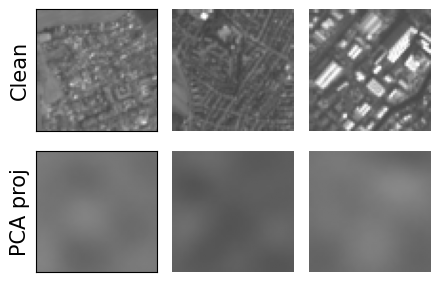

In [28]:
n = 3
idx = [1, 2, 4]
panels = [
    (X_test[idx],                      "Clean"),
    (_imgs(pca_recon_noisy)[idx],      "PCA proj"),
]

fig, axes = plt.subplots(len(panels), n, figsize=(n * 1.5, 1.5 * len(panels)))
for r, (imgs, name) in enumerate(panels):
    for col in range(n):
        axes[r, col].imshow(imgs[col], cmap="gray", vmin=0, vmax=1)
        axes[r, col].axis("off")
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    axes[r, 0].set_ylabel(name, fontsize=15, rotation=90)
# plt.suptitle("Principal components, EuroSAT Dataset — d=18", fontsize=15)
plt.tight_layout()
plt.show()